In [ ]:
# -------------------------------
# NAIVE BAYES CLASSIFIER CODE
# -------------------------------

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv("/content/student_lifestyle_dataset.csv")   # your file

# 2. Preprocessing using Label Encoding
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# 3. Split into Features and Target
X = df.drop("Stress_Level", axis=1)     # replace with your target column
y = df["Stress_Level"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 5. Naive Bayes Model
nb = GaussianNB()
nb.fit(X_train, y_train)

# 6. Prediction & Accuracy
pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Naive Bayes Accuracy: 0.7954545454545454
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       119
           1       0.70      0.92      0.80        36
           2       0.75      0.66      0.70        65

    accuracy                           0.80       220
   macro avg       0.77      0.80      0.78       220
weighted avg       0.80      0.80      0.79       220



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB # Another good option
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- 1. Load and Preprocess Data ---

# Load your dataset (ensure it's clean and preprocessed)
# Replace 'student_stress_data.csv' with the path to your file.
try:
    df = pd.read_csv('/content/student_lifestyle_dataset.csv')
except FileNotFoundError:
    print("Error: student_stress_data.csv not found. Please provide your dataset.")
    exit()

# Assuming your features are in X and the target variable is 'stress_level' (e.g., 0, 1, 2)
# Adjust the column names based on your actual dataset
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

# Handle potential categorical variables using LabelEncoder if not already done
# This loop checks and encodes any object (string) columns
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 2. Train and Evaluate Models ---

def evaluate_model(model, X_test, y_test, name):
    """Trains, predicts, and prints evaluation metrics for a given model."""
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

# Model 1: Support Vector Machine (SVM) with a Radial Basis Function (RBF) kernel
svm_model = SVC(kernel='rbf', random_state=42)
evaluate_model(svm_model, X_test_scaled, y_test, "Support Vector Machine (SVM)")

# Model 2: Random Forest Classifier
# n_estimators=100 is the default and a good starting point
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest Classifier")

# Model 3: Naive Bayes (Gaussian)
# Useful for a quick baseline comparison
nb_model = GaussianNB()
evaluate_model(nb_model, X_test_scaled, y_test, "Naive Bayes")

# --- 3. Feature Importance Analysis (Using Random Forest) ---

print("--- Feature Importance (from Random Forest) ---")
# Feature importance helps identify the major contributing factors to stress
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances)

--- Support Vector Machine (SVM) Results ---
Accuracy: 0.8273
Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.90      0.89       114
         Low       0.70      0.72      0.71        36
    Moderate       0.82      0.76      0.79        70

    accuracy                           0.83       220
   macro avg       0.80      0.79      0.80       220
weighted avg       0.83      0.83      0.83       220

Confusion Matrix:
[[103   7   4]
 [  2  26   8]
 [ 13   4  53]]


--- Random Forest Classifier Results ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       114
         Low       1.00      1.00      1.00        36
    Moderate       1.00      1.00      1.00        70

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

Confus

Random Forest Accuracy: 0.9954545454545455

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       119
           1       1.00      0.97      0.99        36
           2       0.98      1.00      0.99        65

    accuracy                           1.00       220
   macro avg       0.99      0.99      0.99       220
weighted avg       1.00      1.00      1.00       220



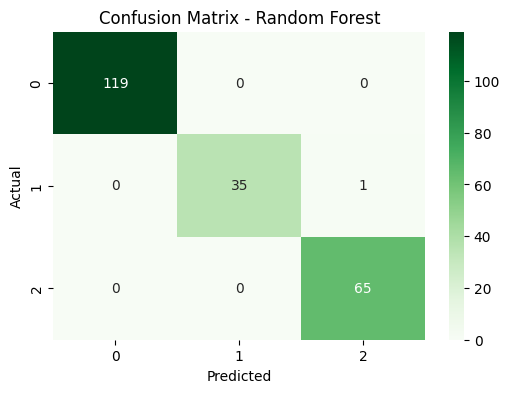


Feature Importance:

                            Feature  Importance
1               Study_Hours_Per_Day    0.433465
3               Sleep_Hours_Per_Day    0.170887
6                               GPA    0.106176
5   Physical_Activity_Hours_Per_Day    0.049017
4              Social_Hours_Per_Day    0.033045
0                        Student_ID    0.030870
2     Extracurricular_Hours_Per_Day    0.024143
8                       self_esteem    0.020697
10                       depression    0.018586
7                     anxiety_level    0.015996
21                    peer_pressure    0.009580
13                breathing_problem    0.009549
17                       study_load    0.009475
14                      noise_level    0.009221
22       extracurricular_activities    0.008743
11                         headache    0.007250
16             academic_performance    0.007245
19           future_career_concerns    0.007160
15                living_conditions    0.007045
18     teacher_stu

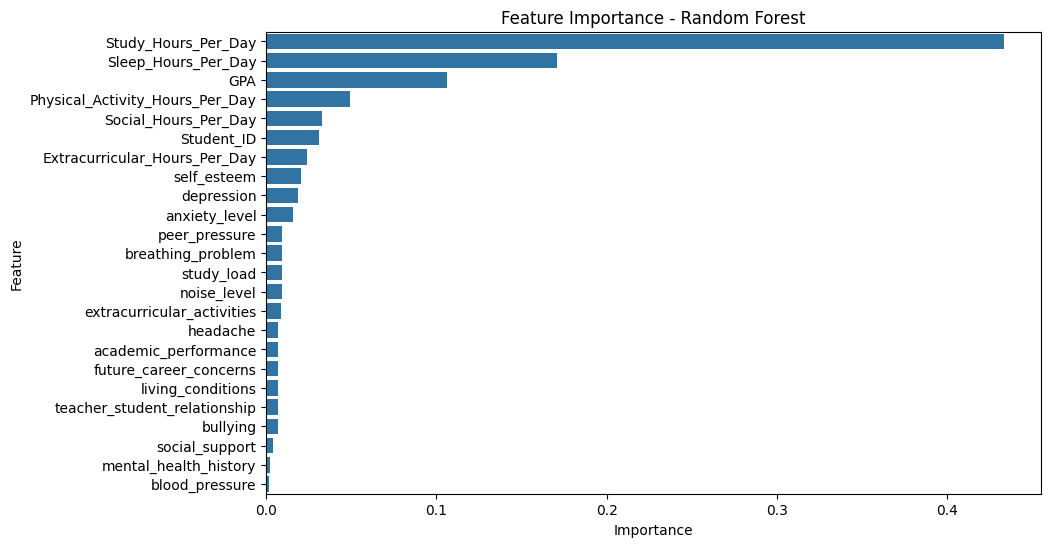

In [ ]:
# -------------------------------------------------------------
#      RANDOM FOREST CLASSIFIER - COMPLETE PIPELINE
#      Includes Heart_Rate, Peer_Pressure, Money + ALL features
# -------------------------------------------------------------

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset
df = pd.read_csv("/content/student_lifestyle_dataset.csv")

# 2. Encode only categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 3. Features and Target
X = df.drop("Stress_Level", axis=1)      # include ALL columns except target
y = df["Stress_Level"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Random Forest Model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# 6. Prediction
rf_pred = rf.predict(X_test)

# 7. Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

# ------------------------------
# 8. CONFUSION MATRIX
# ------------------------------
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ------------------------------
# 9. FEATURE IMPORTANCE
# ------------------------------
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(importances)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Feature Importance - Random Forest")
plt.show()


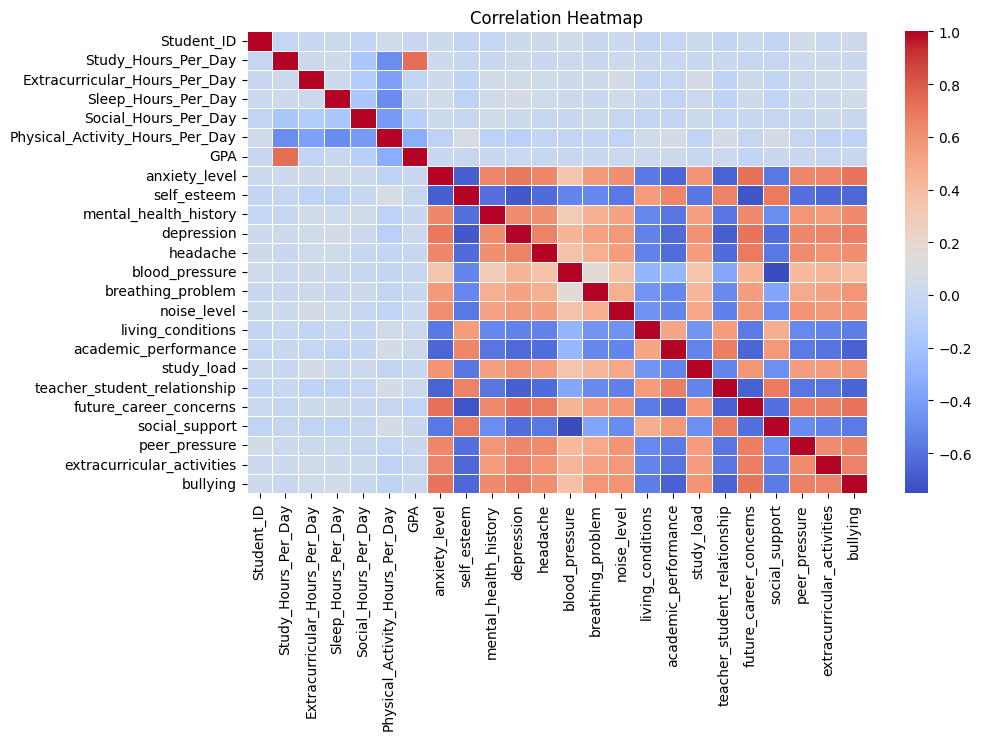

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/student_lifestyle_dataset.csv")          # Reads the CSV file into a DataFrame

# Select only numeric columns
df_numeric = df.select_dtypes(include='number')   # Keeps only numbers (heatmap needs numeric data)

# Compute correlation matrix
corr = df_numeric.corr()                  # Creates a correlation matrix from numeric features

# Plot heatmap
plt.figure(figsize=(10, 6))               # Sets the size of the heatmap image

sns.heatmap(corr,                         # Input correlation matrix
            annot=False,
            cmap='coolwarm',              # Color style of the heatmap
            linewidths=0.5)               # Thin lines between cells

plt.title("Correlation Heatmap")          # Title of the plot
plt.show()                                # Displays the heatmap
